# From sensors to scores analysis
## Step-by-step notebook accompanying my thesis
### Author: Leo Welma (0373885)

This notebook reproduces every figure and table used in the thesis, in the order they appear.
All computation can be found in `pipeline.py` and `descriptives.py`; this notebook only calls those functions
and displays results.

**Before running:** edit `DATA_ROOT` in `config.py` to point at your extracted UAH-DriveSet folder (data used in the thesis, see README_data.md).

| Notebook section            | Thesis section                                          |
|-----------------------------|---------------------------------------------------------|
| 1. Setup                    | —                                                       |
| 2. Data & Descriptives      | 2.2 Descriptives and data structure                     |
| 3. Preprocessing            | 2.3 Preprocessing                                       |
| 4. Feature Engineering      | 2.4–2.6 Segmentation & Feature extraction/selection     |
| 5. Modeling                 | 2.7 Scoring and modeling / 3.1 Classification performance |
| 6. Feature Space Evaluation | 3.2 Feature space evaluation                            |
| 7. Psychometric Evaluation  | 3.4 Psychometric evaluation                             |

---
## 1 — Setup & imports

In [1]:
%matplotlib inline
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

from IPython.display import display, Image
from scipy.stats import pearsonr, ttest_rel
from config import DATA_ROOT, FIG_DIR, TABLE_DIR
import shap
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

from pipeline import (
    discover_trips,
    compute_trip_durations,
    compute_sampling_rates,
    load_all_accel,
    load_all_semantics,
    build_feature_matrix,
    run_modeling_pipeline,
    plot_acf_ari,
    trip_level_clustering_k6,)

from descriptives import (
    participant_metadata,
    trip_durations,
    duration_boxplots,
    timeseries,
    correlation_matrices,
    table_sampling_rates,
    score_distributions,)

# global matplot properties
plt.rcParams.update({'figure.dpi': 150, 'savefig.dpi': 300,'font.size': 10,
                     'axes.titlesize': 11, 'figure.facecolor': 'white',
                     'axes.facecolor': 'white', 'savefig.facecolor': 'white',
                     'text.color': 'black', 'axes.labelcolor': 'black',
                     'xtick.color': 'black', 'ytick.color': 'black',})
plt.style.use('default')

print(f'Data root: {DATA_ROOT}')
print(f'Tables: {TABLE_DIR}')
print(f'Figures: {FIG_DIR}')

Data root: /Users/leowelma/Downloads/UAH-DRIVESET-v1
Tables: output/tables
Figures: output/figures


---
## 2 — Data & Descriptives

The UAH-DriveSet contains 40 driving trips from 6 drivers across 3 conditions
(Normal, Drowsy, Aggressive) on 2 road types (Motorway, Secondary).

In [2]:
trips = discover_trips()
print(f'Shape: {trips.shape}')
display(trips.head())

total trips: 40 trips across 6 drivers
Shape: (40, 8)


,driver,behavior,road,distance_km,datetime_str,trip_folder,age,vehicle
0,D1,NORMAL,SECONDARY,16.0,20151110175712,/Users/leowelma/Downloads/UAH-DRIVESET-v1/D1/2...,34,Citroën C4 (diesel)
1,D1,NORMAL,SECONDARY,16.0,20151110180824,/Users/leowelma/Downloads/UAH-DRIVESET-v1/D1/2...,34,Citroën C4 (diesel)
2,D1,NORMAL,MOTORWAY,25.0,20151111123124,/Users/leowelma/Downloads/UAH-DRIVESET-v1/D1/2...,34,Citroën C4 (diesel)
3,D1,AGGRESSIVE,MOTORWAY,24.0,20151111125233,/Users/leowelma/Downloads/UAH-DRIVESET-v1/D1/2...,34,Citroën C4 (diesel)
4,D1,DROWSY,MOTORWAY,25.0,20151111132348,/Users/leowelma/Downloads/UAH-DRIVESET-v1/D1/2...,34,Citroën C4 (diesel)


### Table 1 — Participant & vehicle metadata  *(thesis Table 1)*

In [3]:
t1 = participant_metadata(trips)
display(t1)

,Driver,Age,Vehicle,MOT_NOR,MOT_DRO,MOT_AGG,SEC_NOR,SEC_DRO,SEC_AGG
0,D1,34,Citroën C4 (diesel),1,1,1,2,1,1
1,D2,20,Opel Corsa (gasoline),1,1,1,2,1,1
2,D3,22,Citroën C4 (diesel),1,1,1,2,1,1
3,D4,27,Opel Astra (diesel),1,1,1,2,1,1
4,D5,30,Volkswagen Golf (diesel),1,1,1,2,1,1
5,D6,46,Nissan Juke (gasoline),1,1,1,1,1,—


### Trip durations  *(thesis Table 2 / Figure 2)*

In [4]:
trips = compute_trip_durations(trips)
t2 = trip_durations(trips)
display(t2)

,Behavior,Road,N_trips,Mean_min,SD_min,Min_min,Max_min,Total_min
0,NORMAL,MOTORWAY,6,15.8,1.0,14.6,17.2,94.8
1,NORMAL,SECONDARY,11,11.6,0.7,10.4,13.1,127.2
2,DROWSY,MOTORWAY,6,17.0,1.0,15.8,18.2,102.0
3,DROWSY,SECONDARY,6,11.0,1.3,8.4,12.1,66.0
4,AGGRESSIVE,MOTORWAY,6,14.2,1.2,12.3,15.6,85.2
5,AGGRESSIVE,SECONDARY,5,9.8,1.8,7.1,11.4,48.9


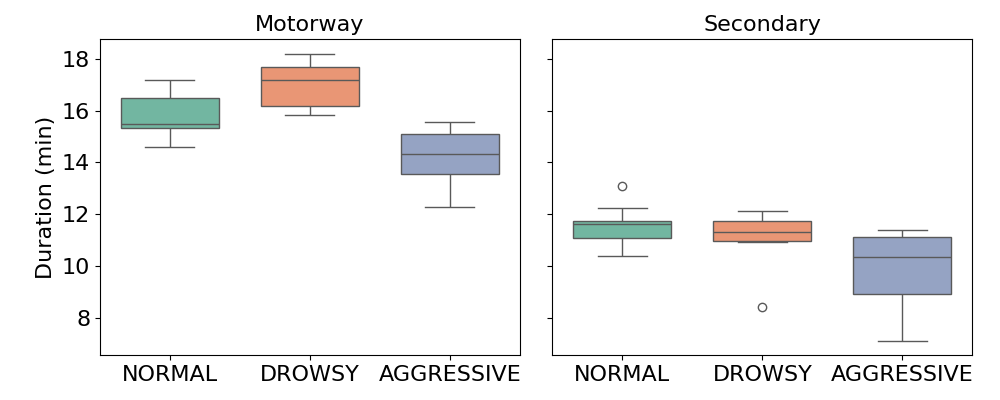

In [5]:
duration_boxplots(trips)
display(Image(FIG_DIR / 'duration_boxplots.png'))

---
## 3 — Preprocessing

Sampling rate diagnostics confirm ~9.9 Hz; linear interpolation resamples to exactly 10 Hz
for consistent window sizes.

### Sampling rate diagnostics  *(thesis Table 3)*

In [6]:
rate_df = compute_sampling_rates(trips)
t_rates = table_sampling_rates(rate_df)
display(t_rates)

,N trips,Mean Hz,SD Hz,Min Hz,Max Hz,Mean samples per trip
0,1,9.89,NaN,9.89,9.89,6170.0


### Load accelerometer data (resampled to 10 Hz)

In [7]:
all_accel = load_all_accel(trips, resample_hz=10.0)
print(f'Shape: {all_accel.shape}')
print(f'Columns: {list(all_accel.columns)}')

total accelerometer samples: 314,444
Shape: (314444, 15)
Columns: ['timestamp', 'activation', 'acc_x', 'acc_y', 'acc_z', 'acc_x_kf', 'acc_y_kf', 'acc_z_kf', 'roll', 'pitch', 'yaw', 'driver', 'behavior', 'road', 'trip_id']


### Representative 30-second time series  *(thesis Figure 3)*

30-second excerpts from Motorway sessions. The bar strip above each subplot illustrates
the 5-second sliding-window segmentation (50 % overlap) applied.

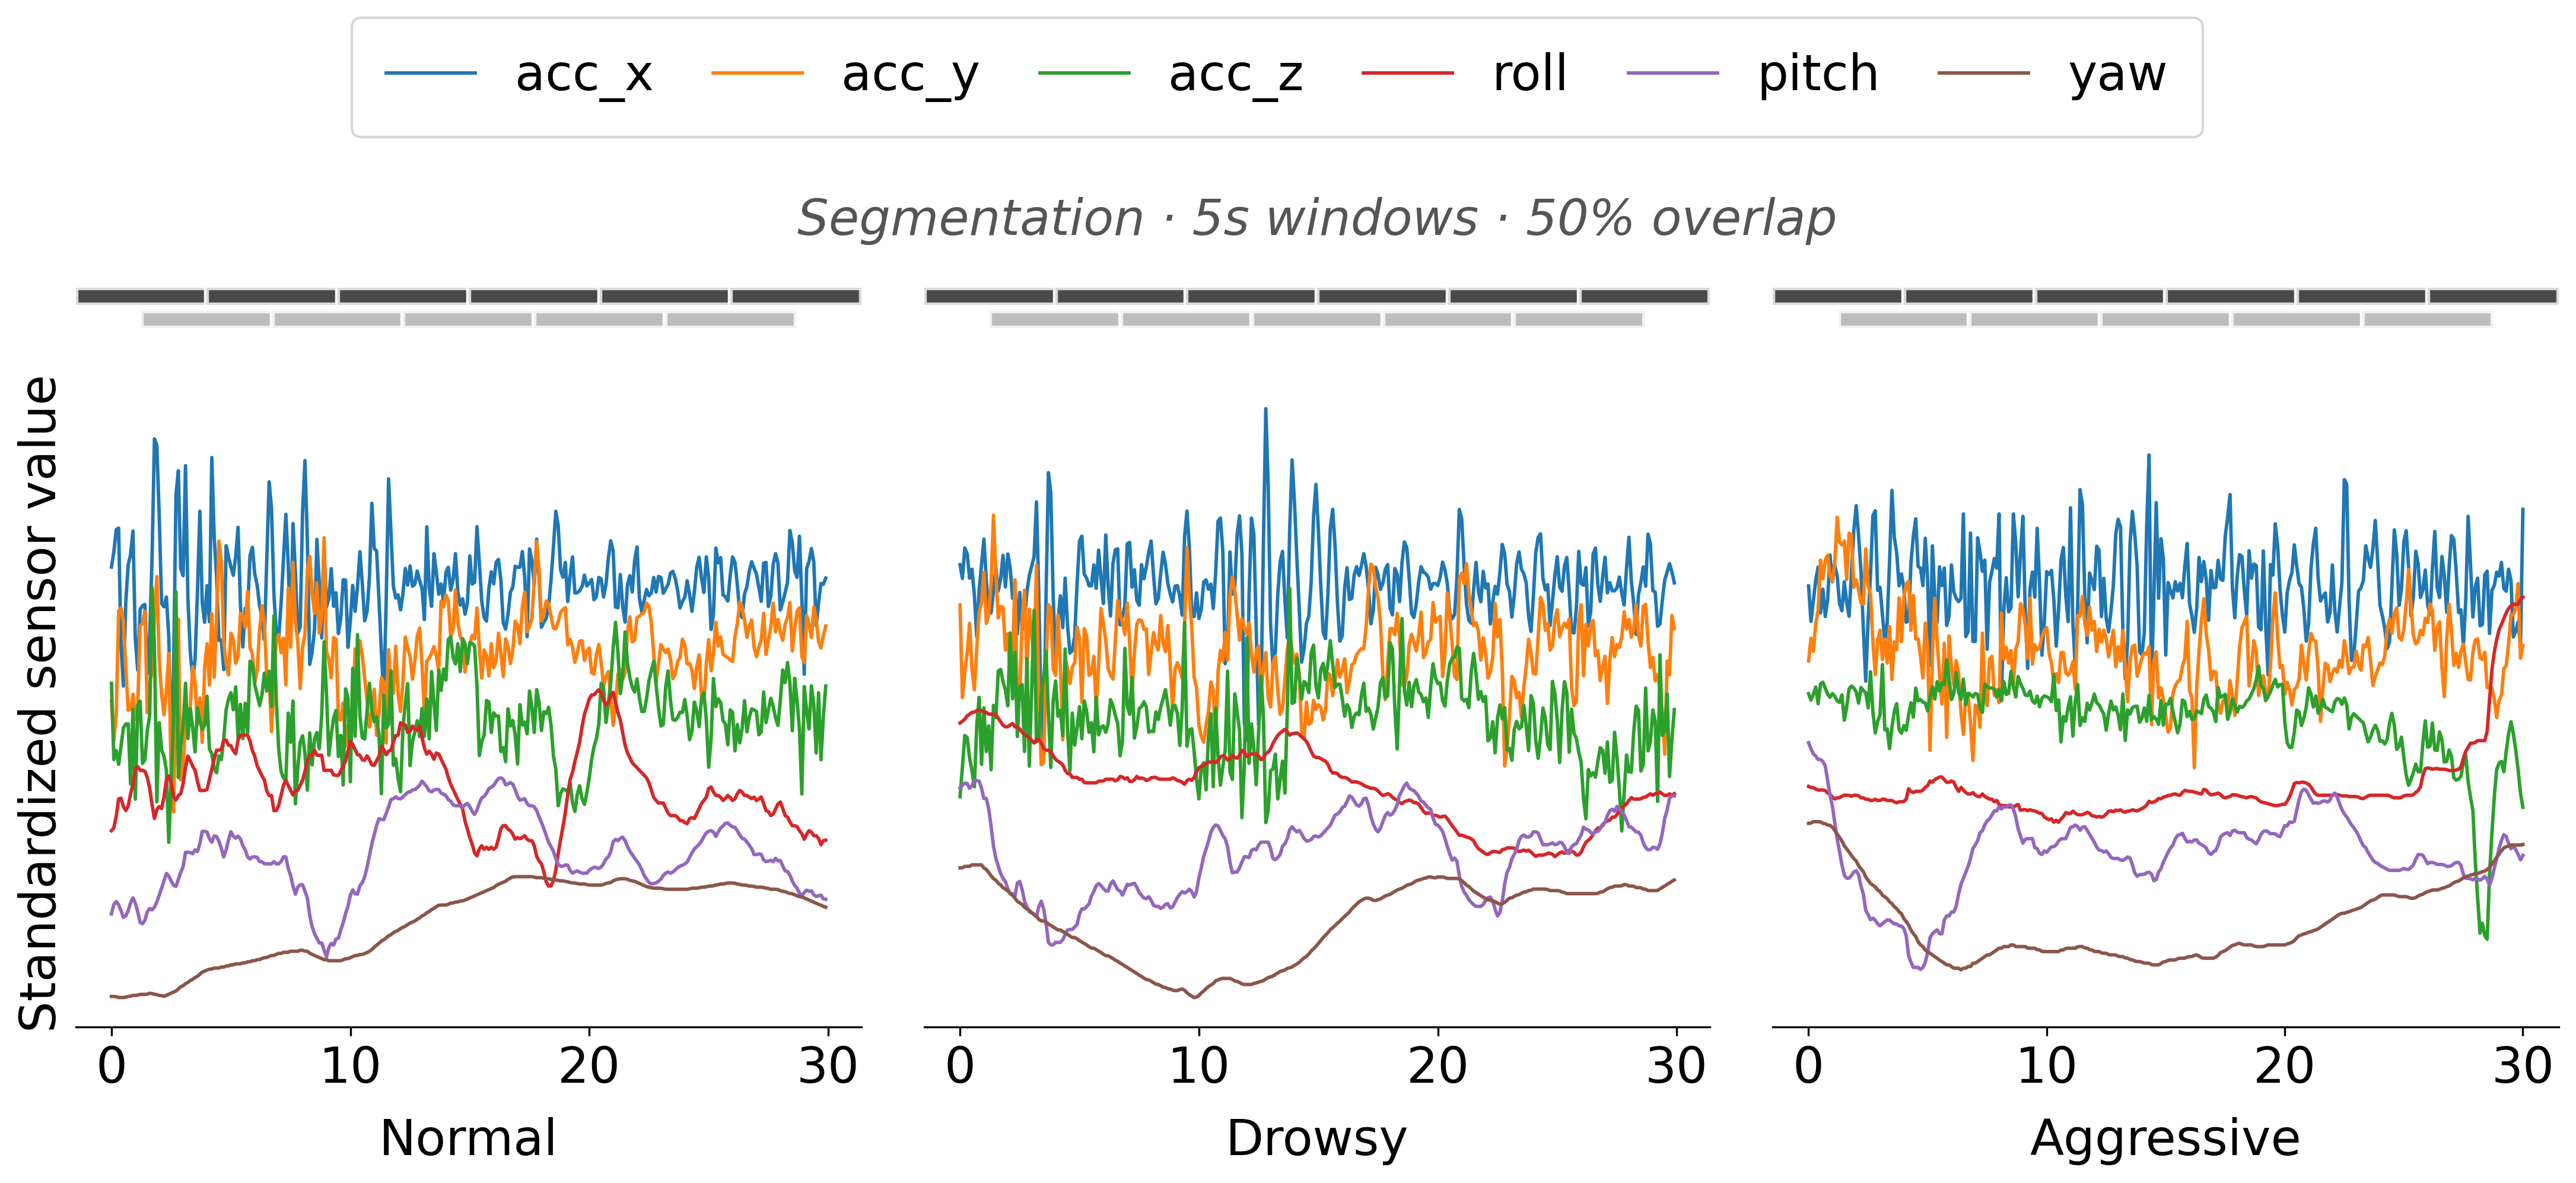

In [8]:
timeseries(all_accel)
display(Image(FIG_DIR / 'timeseries.png'))

### Cross-channel correlation matrices by condition  *(thesis Figure 4)*

Normal driving: near-zero inter-channel correlations (smooth, decoupled motion).  
Drowsy / Aggressive: correlations up to 0.85 — coupled motion across sensor axes.

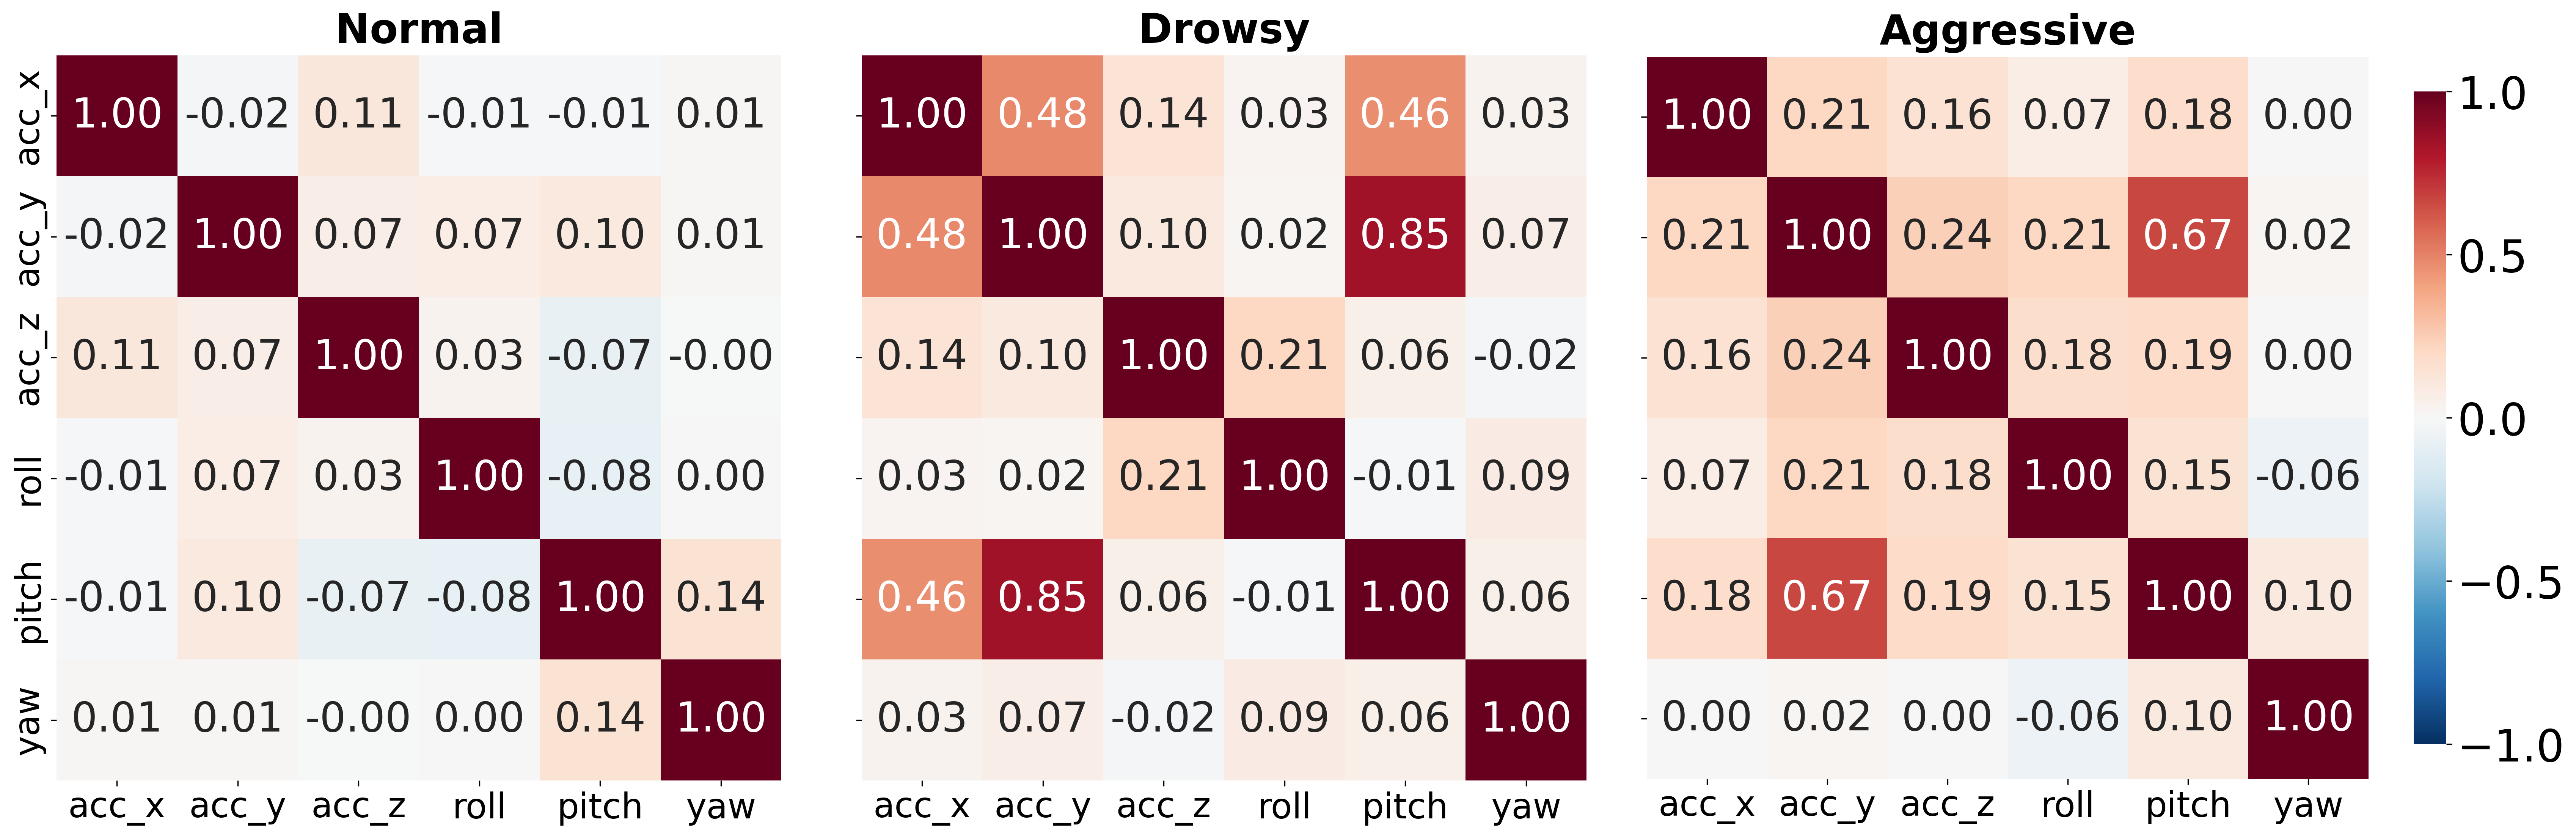

In [9]:
correlation_matrices(all_accel)
display(Image(FIG_DIR / 'correlation_matrices.png'))

---
## 4 — Feature Engineering

**Segmentation** ( Section 2.4): 5-second windows, 50 % overlap → 12 517 windows.
**Feature extraction** (Section 2.5): 147 features per window across 5 groups:
statistical moments, temporal structure, frequency domain, sample entropy, cross-channel correlations.  
**Feature selection** (Section 2.6): near-zero-variance filter → collinearity filter → mutual information ranking.

In [10]:
X_df, y, meta, trip_results, within_results = build_feature_matrix(
    all_accel, run_selection=True)

print("\n")
print("--- " * 12)
print(f'\nFeature matrix : {X_df.shape[0]:} windows × {X_df.shape[1]} features')
print(f'Label distribution:')
display(meta['behavior'].value_counts().rename('n_windows').to_frame())


---- ---- Step 1: Segmentation ----  ----
segmentation resulted in 12517 windows

---- ---- Step 2: Feature Extraction ----  ----
    features extracted: 1000/12517
    features extracted: 2000/12517
    features extracted: 3000/12517
    features extracted: 4000/12517
    features extracted: 5000/12517
    features extracted: 6000/12517
    features extracted: 7000/12517
    features extracted: 8000/12517
    features extracted: 9000/12517
    features extracted: 10000/12517
    features extracted: 11000/12517
    features extracted: 12000/12517
------------------------------------------------------------
feature extraction complete: 12517 windows x 147 features
------------------------------------------------------------

---- ---- ---- Step 3: Feature Selection ---- ---- ----
near zero variance filter removed 37 features (110 left)
collinearity filter removed 8 features (102 left)
------------------------------------------------------------

features by MI (Top 10):
yaw_mean       

,n_windows
behavior,
NORMAL,5301
DROWSY,4013
AGGRESSIVE,3203


### Top 10 features by mutual information  *(thesis Table 5)*

In [11]:
mi_report = pd.read_csv(TABLE_DIR / 'feature_selection.csv')
top10 = (mi_report[mi_report['kept_final']]
         .nlargest(10, 'mi_score')[['feature', 'mi_score']]
         .reset_index(drop=True))
top10.index += 1
display(top10.rename(columns={'feature': 'Feature', 'mi_score': 'MI Score'}))

,Feature,MI Score
1,yaw_mean,0.195519
2,acc_z_min,0.137832
3,acc_y_max,0.137642
4,acc_x_max,0.126055
5,acc_y_min,0.121859
6,yaw_rms,0.117294
7,acc_x_min,0.100079
8,acc_z_range,0.100040
9,roll_max,0.090522
10,roll_min,0.085714


### PCA scatter (window level)  *(thesis Figure 7)*

PC1 explains 11.9 % of variance. Normal windows score highest on PC1 (M = +0.87),
confirming a condition-relevant axis, but the majority of variance is driven by other factors.

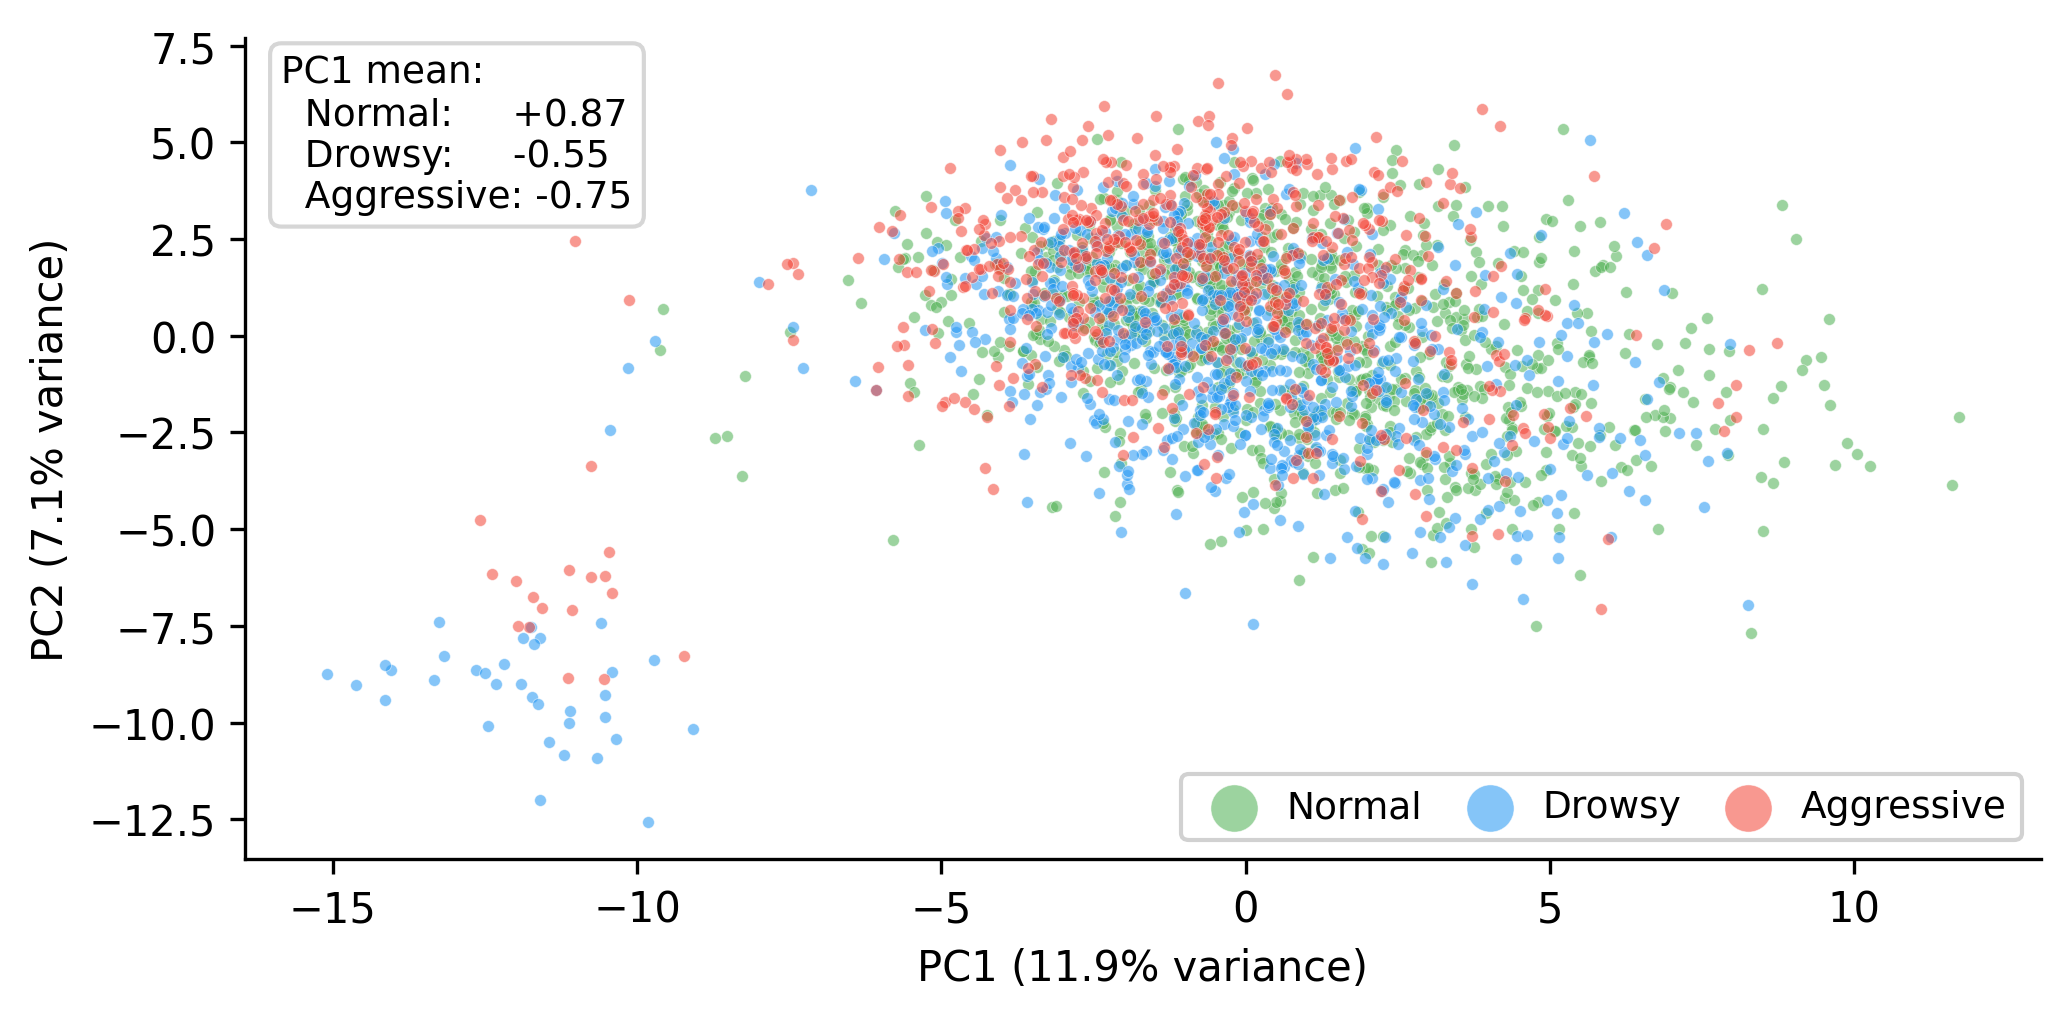

,PC1_var_explained,PC1_mean_NORMAL,PC1_mean_DROWSY,PC1_mean_AGGRESSIVE,PC1_aligns_with_Normal
0,0.1193,0.8673,-0.5493,-0.7472,True


In [12]:
display(Image(FIG_DIR / 'pca_scatter.png'))
display(pd.read_csv(TABLE_DIR / 'pca_window_report.csv'))

---
## §5 — Modeling  *(Thesis §2.6 / §3.1)*

Three classifiers (Logistic Regression, Random Forest, XGBoost) evaluated with
Leave-One-Driver-Out (LODO) cross-validation + isotonic calibration.

Primary score: **P(Normal)** — posterior probability of belonging to the Normal condition reference class.

In [13]:
results = run_modeling_pipeline(X_df, y, meta)


--- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- 
  LogisticRegression — Leave-One-Driver-Out CV
--- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- 
  held out D1: acc=0.652  macro F1=0.621  ECE(Normal)=0.073
  held out D2: acc=0.750  macro F1=0.739  ECE(Normal)=0.075
  held out D3: acc=0.687  macro F1=0.691  ECE(Normal)=0.077
  held out D4: acc=0.660  macro F1=0.648  ECE(Normal)=0.074
  held out D5: acc=0.729  macro F1=0.724  ECE(Normal)=0.083
  held out D6: acc=0.682  macro F1=0.665  ECE(Normal)=0.082

 mean across folds:
 accuracy: 0.693 (SD=0.039)
 macro F1: 0.681 (SD=0.045)
 ECE(Normal): 0.077 (SD=0.004)

--- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- 
  RandomForest — Leave-One-Driver-Out CV
--- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- 
  held out D1: acc=0.895  macro F1=0.891  ECE(Normal)=0.042
  held out D2: acc=0.865  macro F1=0.862  ECE(Normal)=0.033
  held out D3: acc=0.845  macro F1=0.846  ECE(Normal)=0.054
  

### Table — Model comparison  *(thesis Table model_comparison)*

In [14]:
display(results['summary_table'])

,Model,Accuracy,Macro F1,F1 Normal,F1 Drowsy,F1 Aggressive,ECE Normal
0,LogisticRegression,0.693 (0.039),0.681 (0.045),0.726 (0.044),0.676 (0.062),0.643 (0.094),0.077 (0.004)
1,RandomForest,0.862 (0.023),0.859 (0.022),0.873 (0.027),0.855 (0.039),0.849 (0.023),0.048 (0.011)
2,XGBoost,0.920 (0.023),0.919 (0.022),0.925 (0.027),0.917 (0.038),0.913 (0.017),0.015 (0.005)


### Macro F1 per held-out driver  *(thesis Figure 5)*

Stable F1 across all six drivers confirms generalization.
No systematic performance drop for any specific driver or vehicle.

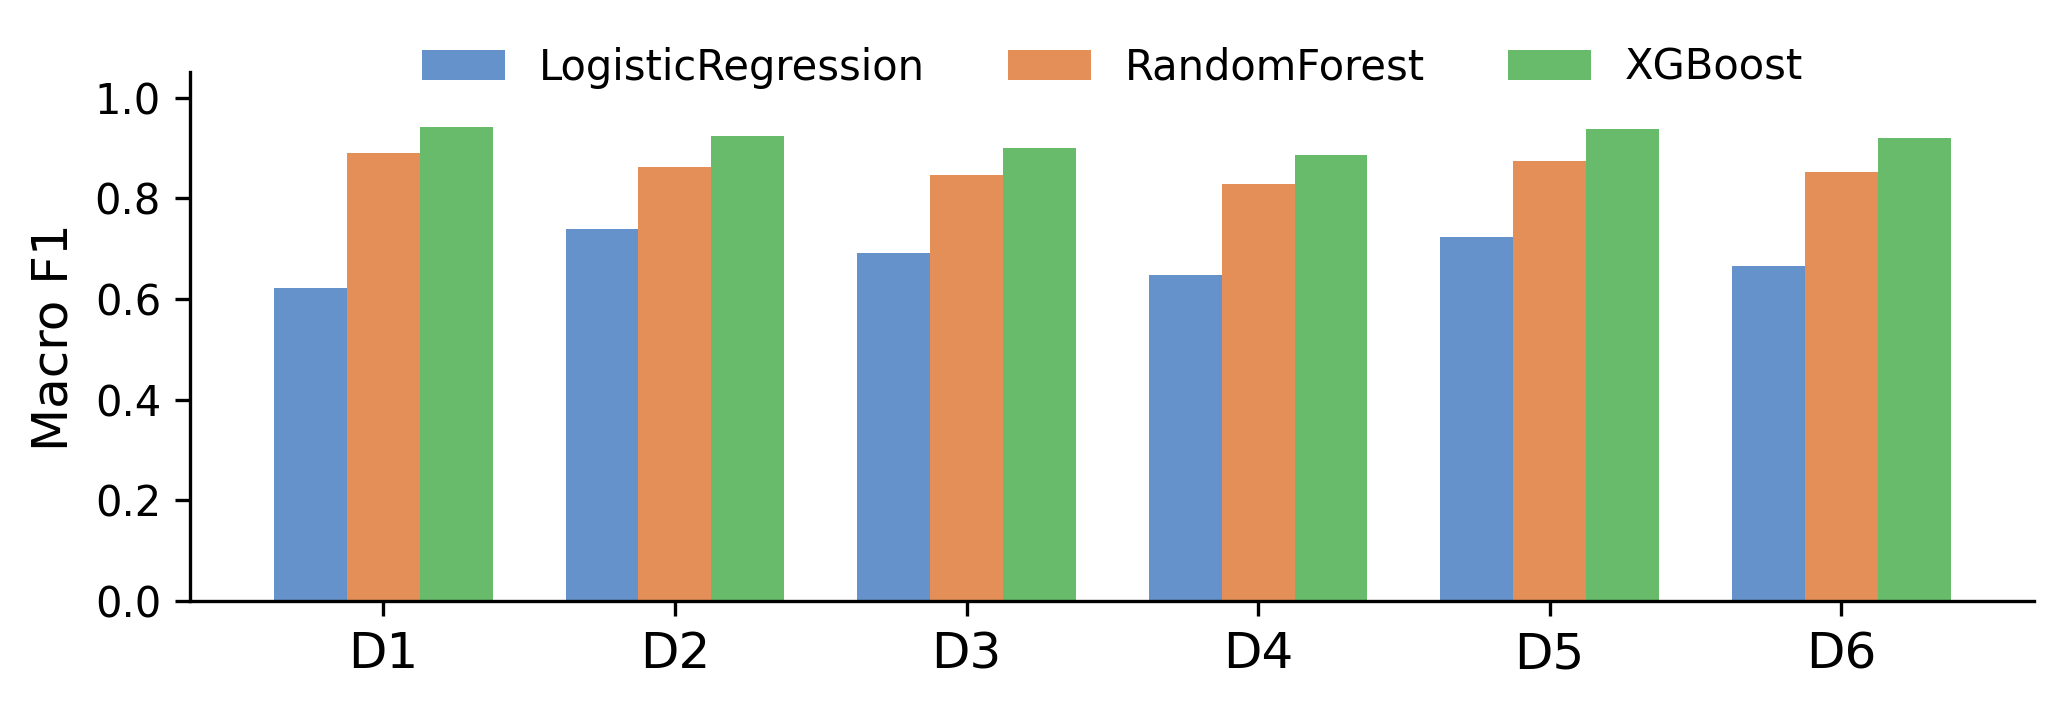

In [15]:
display(Image(FIG_DIR / 'lodo_performance.png'))

### Person-level P(Normal) by condition  *(thesis Figure 6)*

Expected ordering confirmed: Normal > Drowsy ≈ Aggressive across all models.
Separation improves from LR → RF → XGBoost.

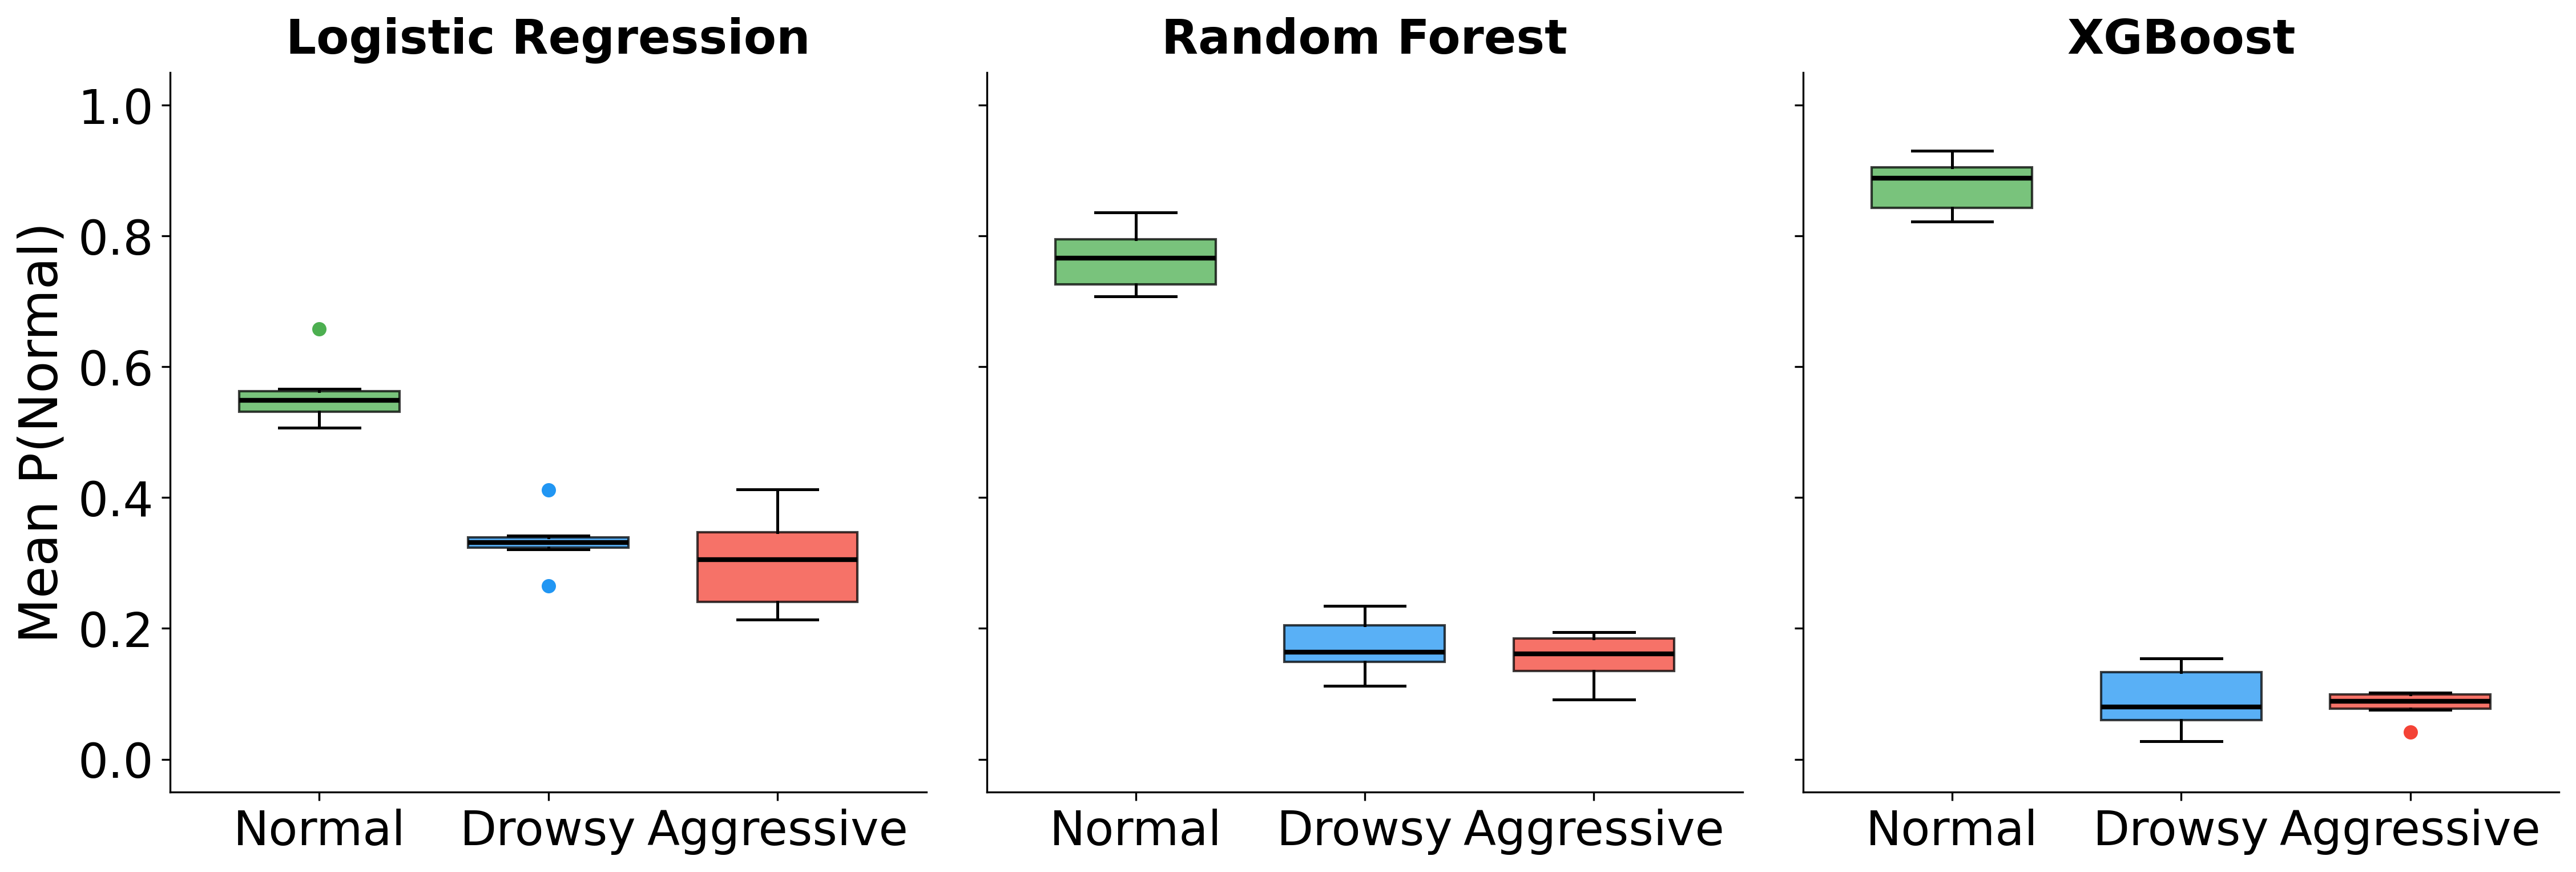

In [16]:
score_distributions(pd.read_csv(TABLE_DIR / 'person_scores.csv'))
display(Image(FIG_DIR / 'score_distributions.png'))

### Calibration curves  *(thesis Figure 10)*

XGBoost follows the diagonal most closely (ECE = 0.012).

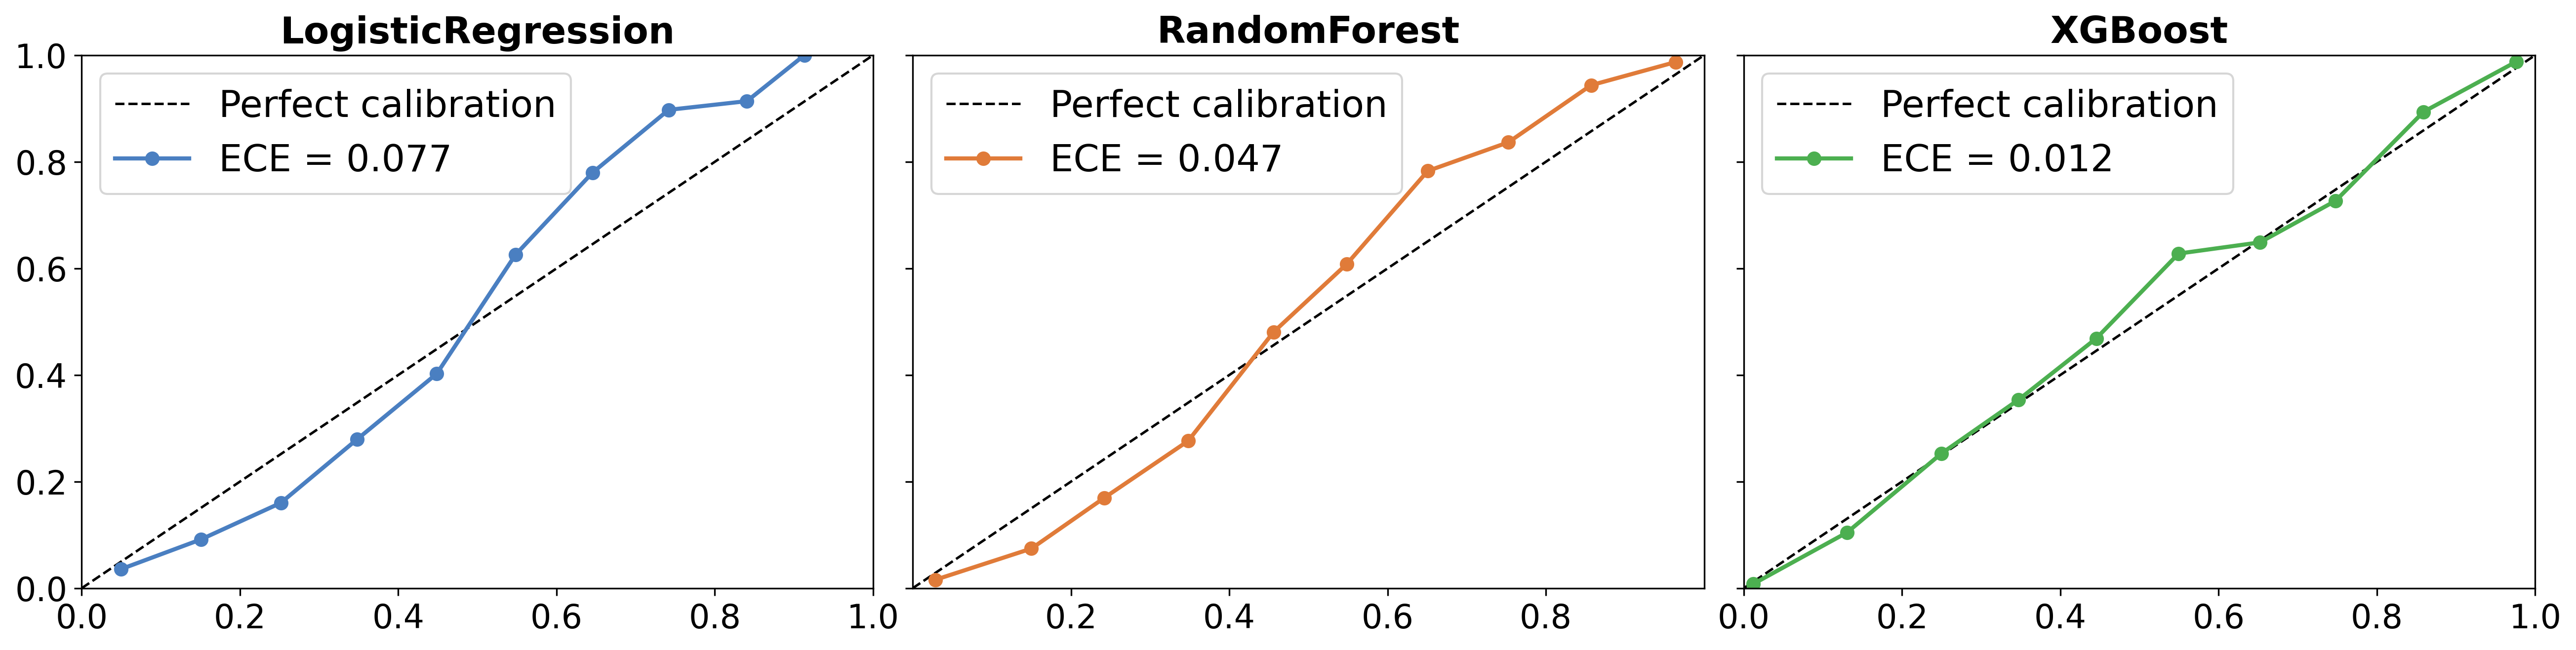

In [17]:
display(Image(FIG_DIR / 'fig_calibration_curves.png'))

---
## 6 — Feature Space Evaluation

Unsupervised analyses test whether the condition structure is recoverable without access to condition labels (RQ2).

### Trip-level clustering (k = 3)  *(thesis Figure 8)*

ARI = 0.006 (near chance); 33 of 40 trips collapse into one cluster.
Condition variance is dominated by person- and vehicle-level differences.

,n_trips,ARI_full,NMI_full,ARI_pca,NMI_pca,pca_components
0,40,0.0064,0.04,0.0064,0.04,10



Contingency Table (PCA-reduced):


,AGGRESSIVE,DROWSY,NORMAL
Cluster,,,
0,1,2,2
1,9,9,15
2,1,1,0


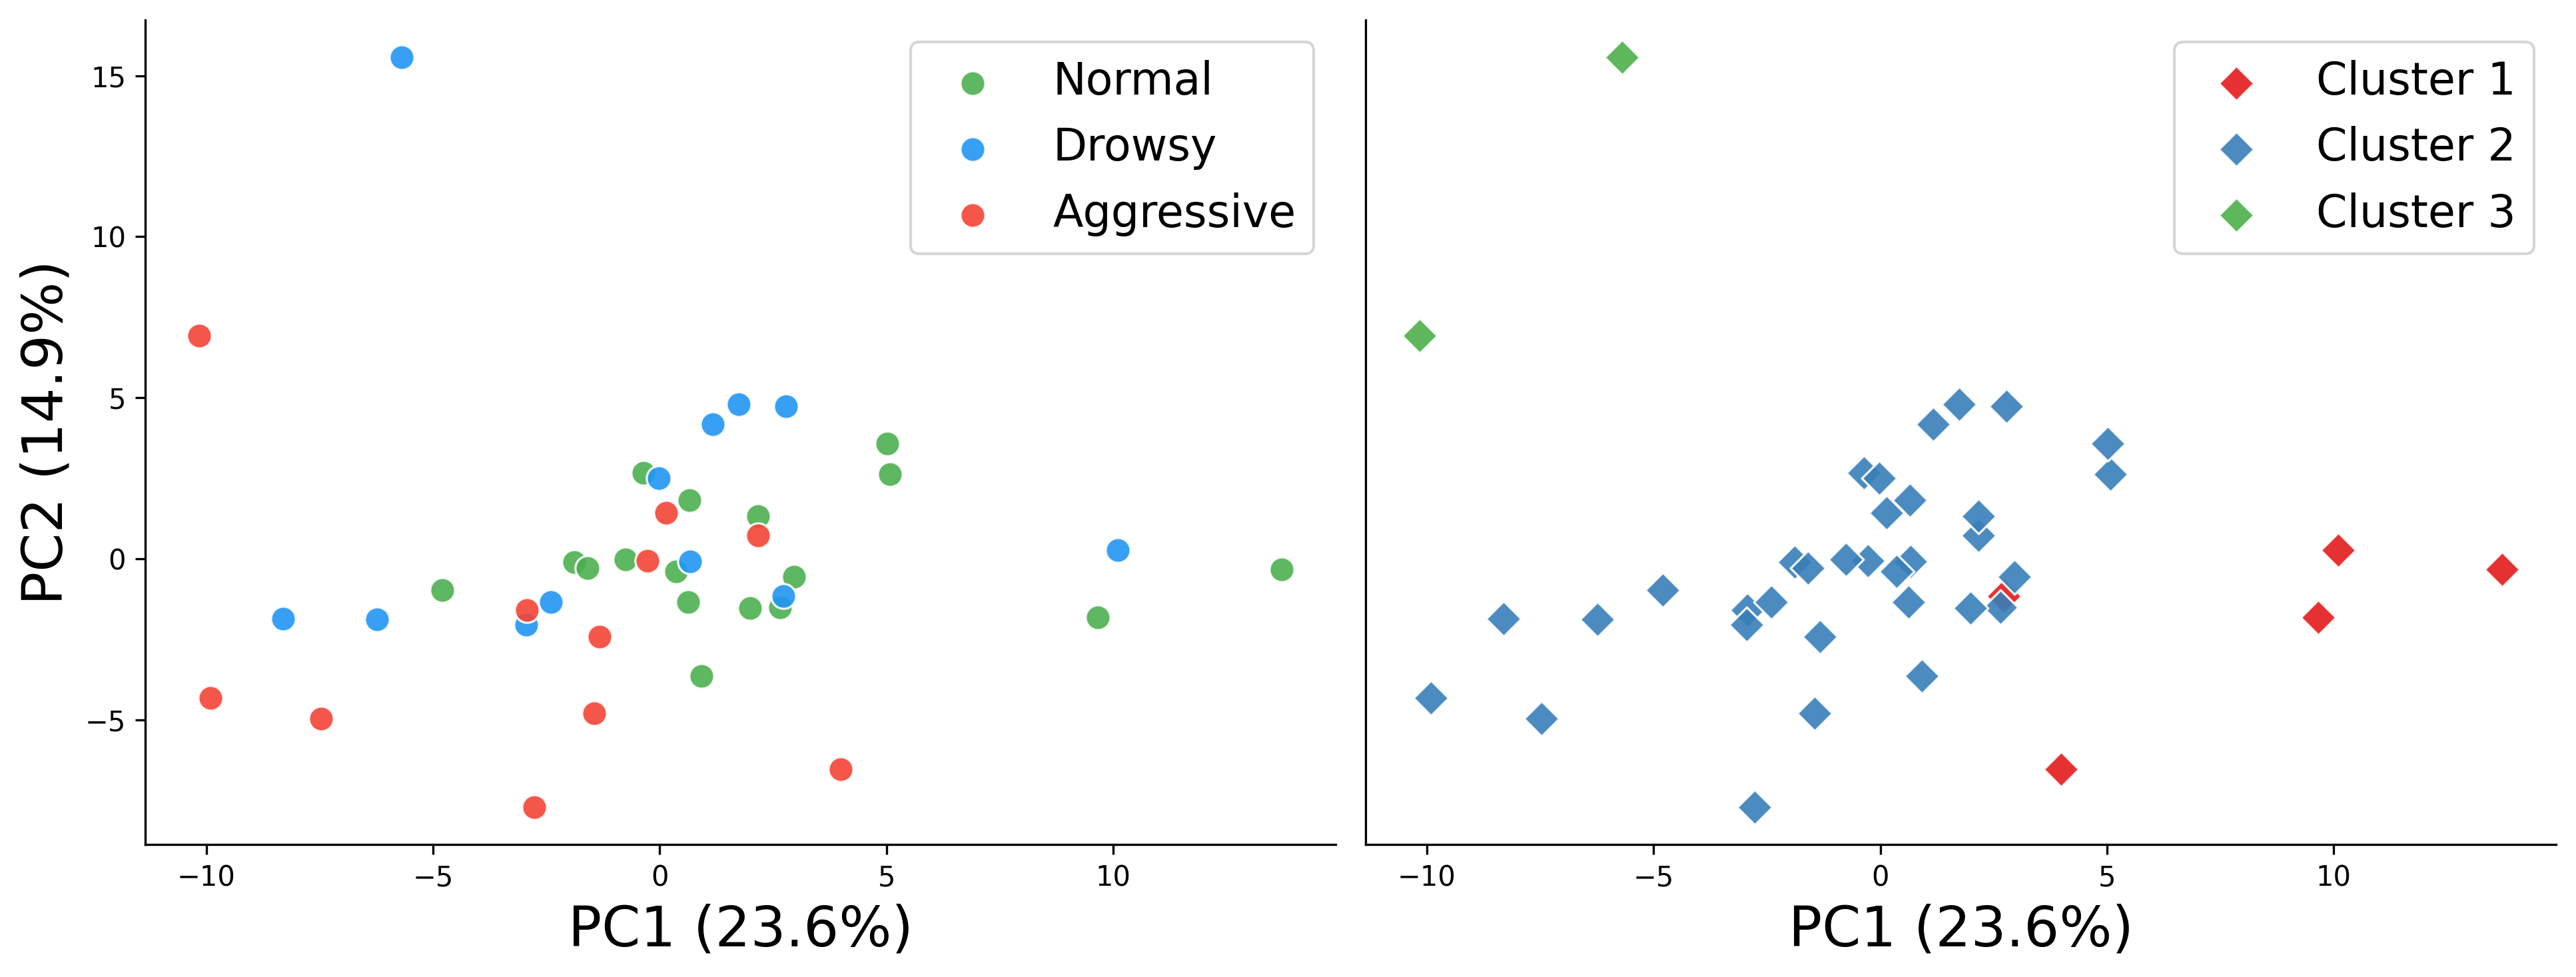

In [18]:
display(pd.read_csv(TABLE_DIR / 'clustering_k3.csv'))
print('\nContingency Table (PCA-reduced):')
display(pd.read_csv(TABLE_DIR / 'cont_tab_pca_k3.csv', index_col=0))
display(Image(FIG_DIR / 'clustering_k3.png', width=900))

### Trip-level clustering (k = 6)  *(thesis Figure 9)*

With k = 6: ARI vs condition (0.179) > ARI vs driver identity (0.148).
Six clusters begin to capture condition-within-driver subgroups.

,ARI_vs_driver,ARI_vs_condition
0,0.148,0.1785


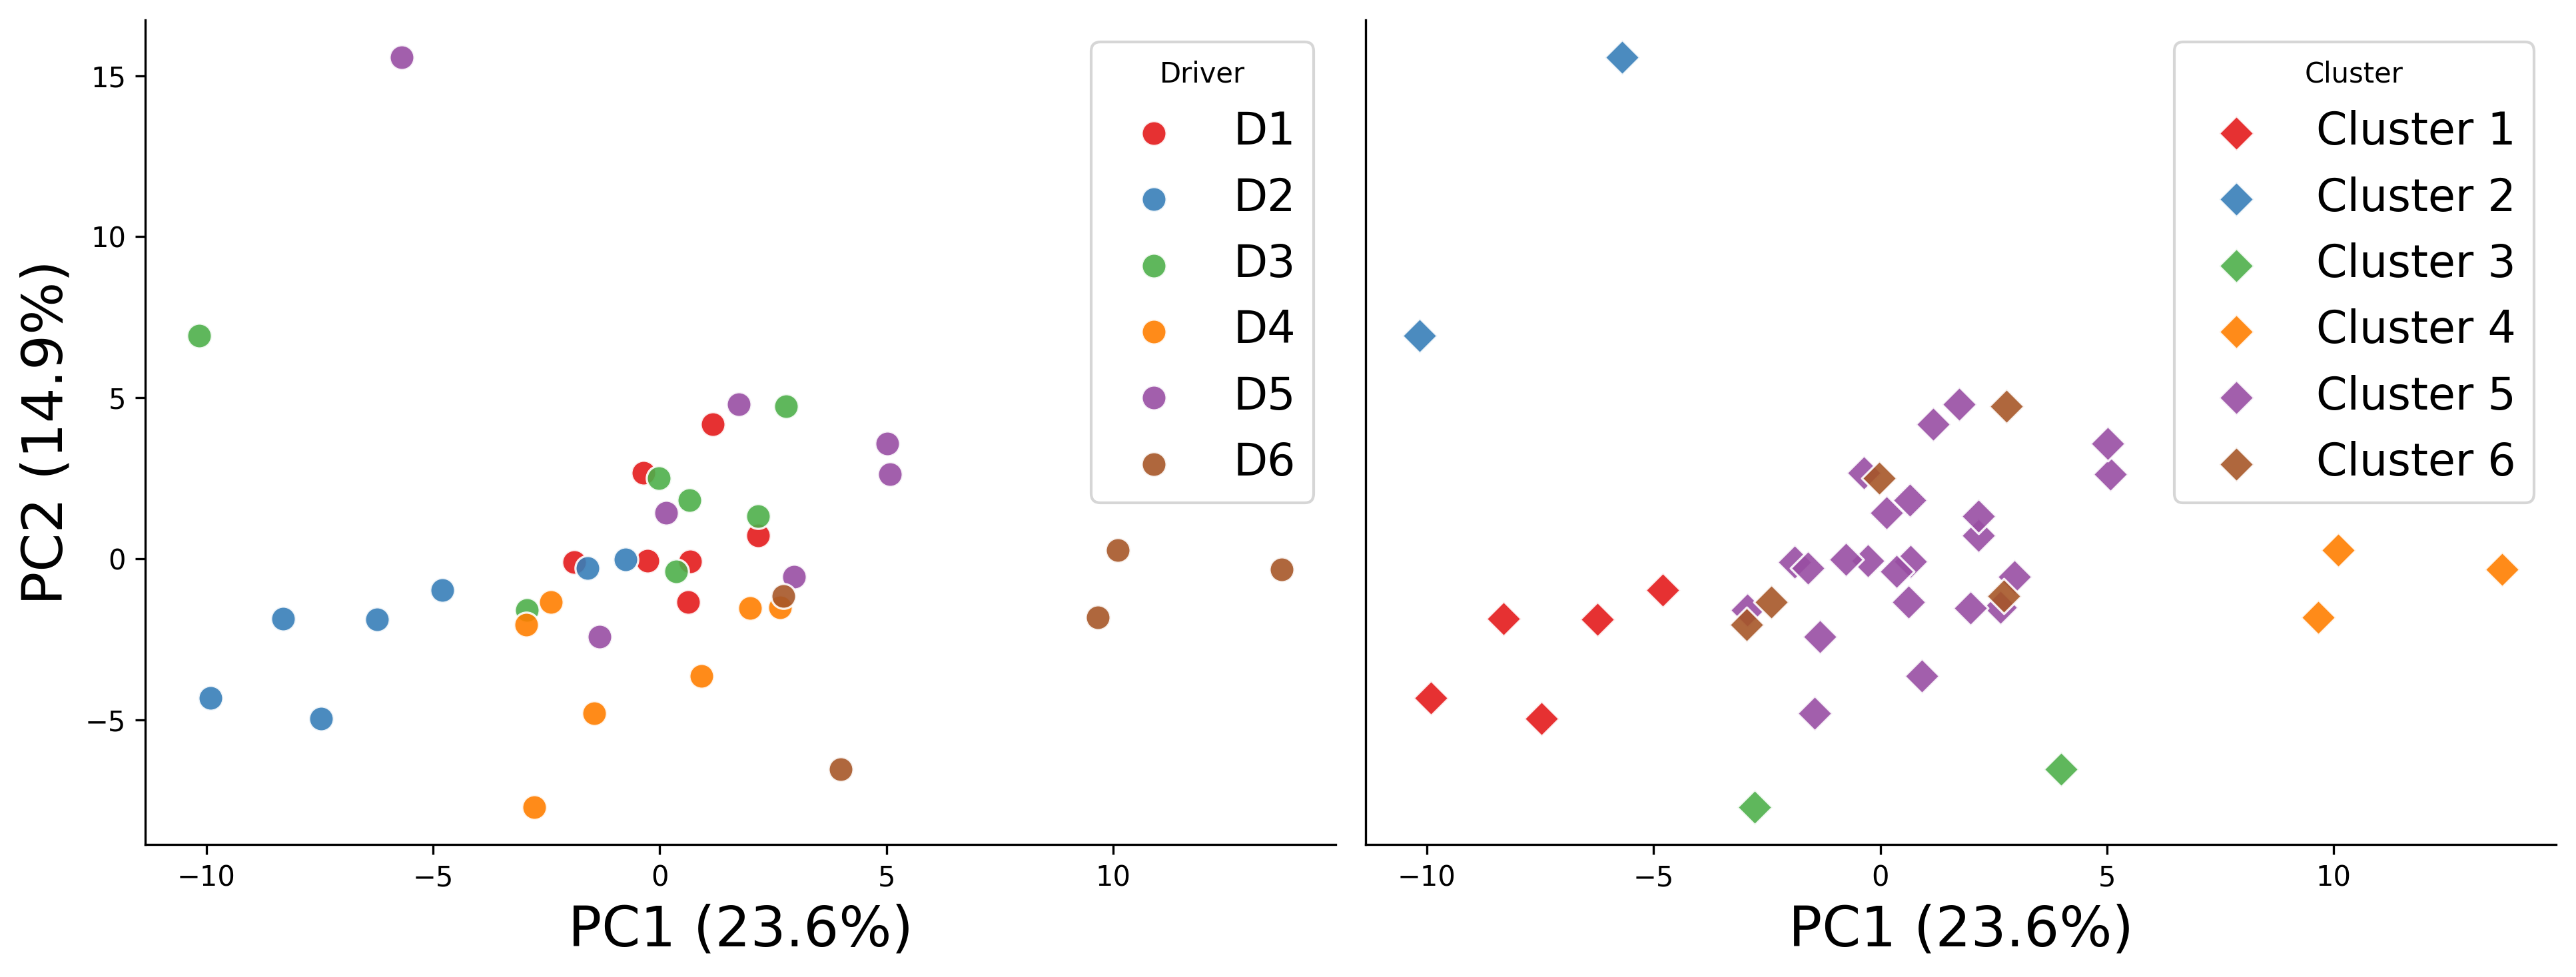

In [19]:
display(pd.read_csv(TABLE_DIR / 'clustering_k6.csv'))
display(Image(FIG_DIR / 'clustering_k6.png', width=900))

### Within-driver clustering

Holding driver identity constant: mean ARI = 0.050 (vs cross-driver ARI = 0.006).

In [20]:
within_df = pd.read_csv(TABLE_DIR / 'within_driver_clustering.csv')
display(within_df)
print(f"\nMean within-driver ARI: {within_df['ARI'].mean():.4f} (SD={within_df['ARI'].std():.4f})")

,Driver,N_windows,ARI,NMI
0,D1,1944,0.0206,0.0129
1,D2,2145,0.0419,0.0573
2,D3,2196,0.0491,0.0935
3,D4,2294,0.0547,0.0551
4,D5,2134,0.0570,0.1198
5,D6,1804,0.0773,0.0766



Mean within-driver ARI: 0.0501 (SD=0.0187)


### ACF + within-driver ARI combined  *(thesis Figure 11)*

Left: lag-1 ACF = 0.307 confirms temporal autocorrelation within trips.
Right: per-driver ARI values with cross-driver baseline.

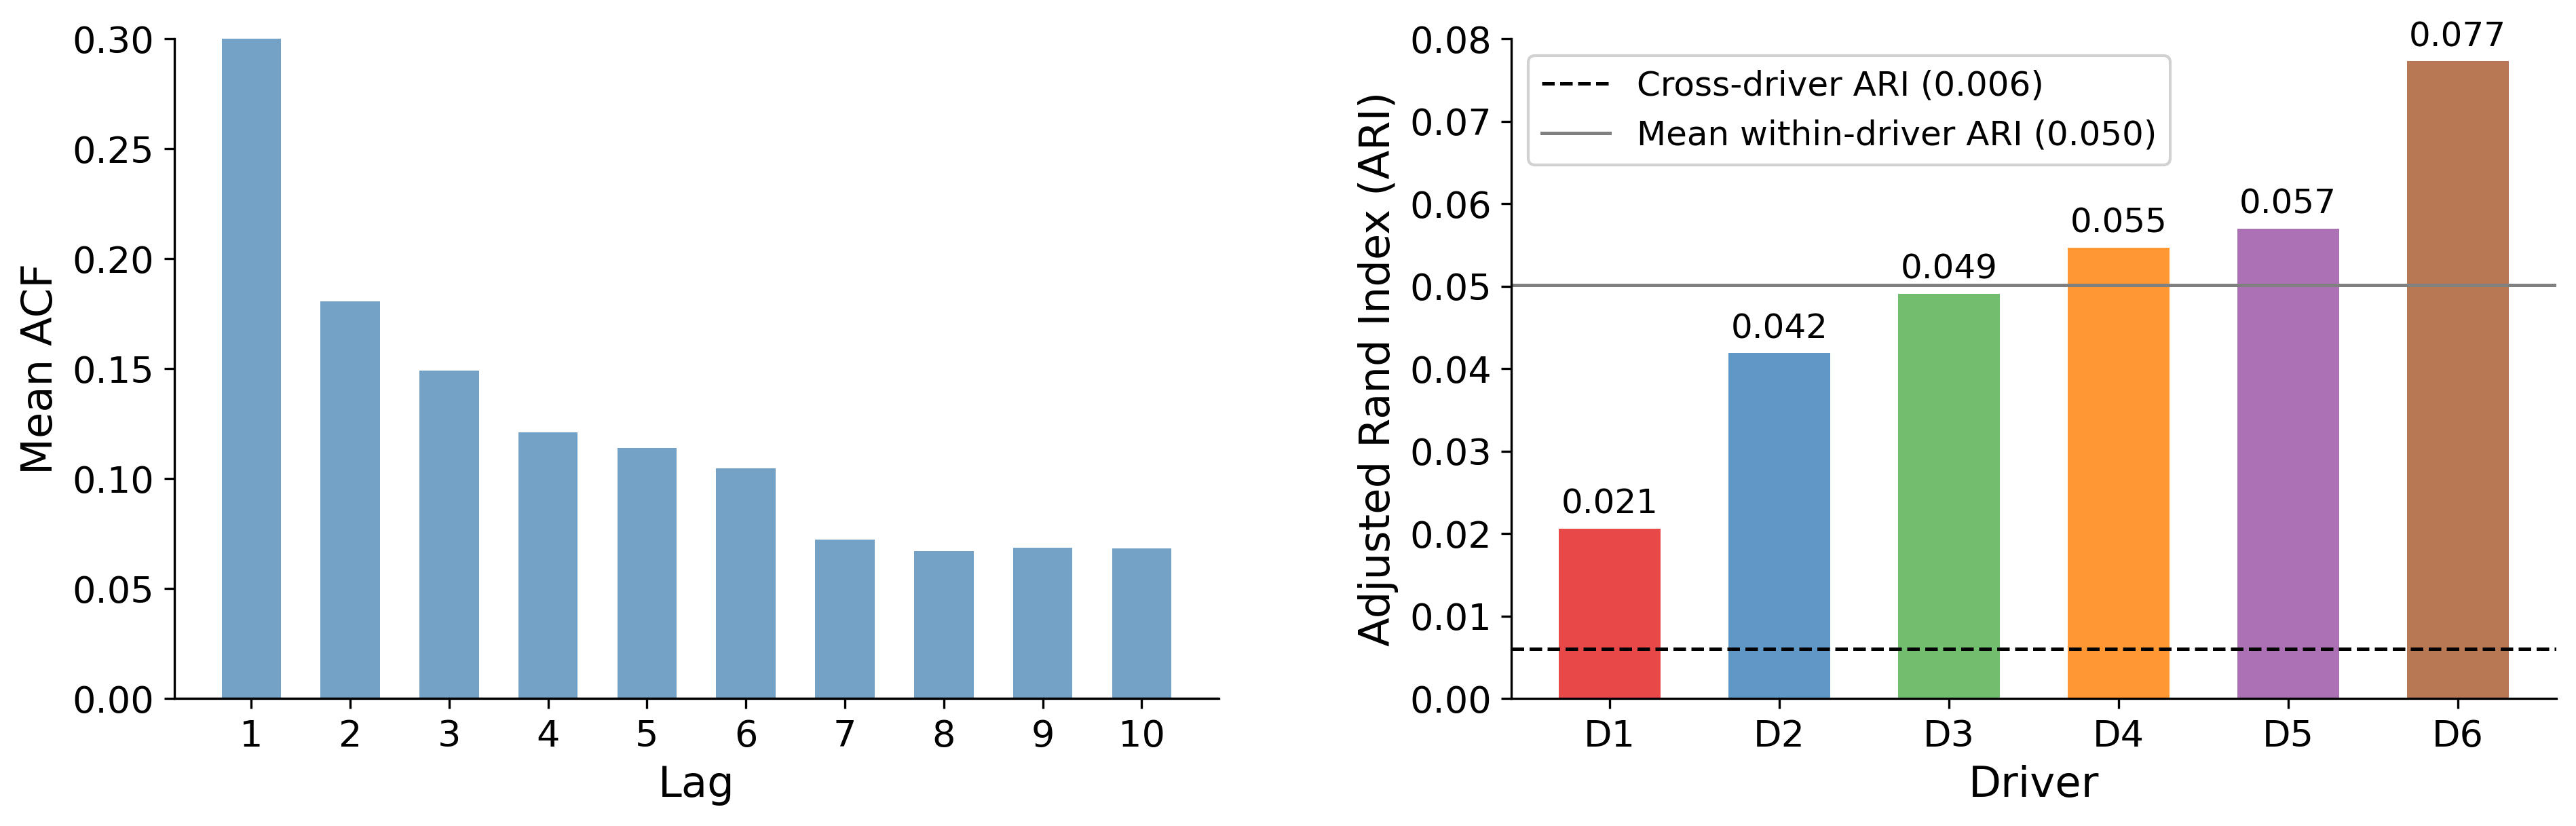

In [21]:
window_scores = pd.read_csv(TABLE_DIR / 'window_scores.csv')
within_driver_results = dict(zip(within_df['Driver'], within_df['ARI']))

plot_acf_ari(window_scores, within_driver_results)
display(Image(FIG_DIR / 'acf_ari.png'))

---
## 7 — Psychometric Evaluation

Evaluation criteria (C1–C6) as defined in the thesis Introduction.

| No | Criterion             | What it tests |
|----|-----------------------|---|
| C1 | Calibration           | P(Normal) matches observed class proportions |
| C2 | Generalisation        | Scores hold for unseen drivers |
| C3 | Score consistency     | Aggregated scores are stable within trips |
| C4 | Discriminant validity | Scores separate behavioral conditions |
| C5 | Feature importance    | Model responds to theoretically expected features |
| C6 | Convergent validity   | Scores align with independent external criterion |

In [22]:
window_scores = pd.read_csv(TABLE_DIR / 'window_scores.csv')
trip_scores = pd.read_csv(TABLE_DIR / 'trip_scores.csv')
person_scores = pd.read_csv(TABLE_DIR / 'person_scores.csv')
print(f'Windows loaded: {len(window_scores):,}')
print(f'Trips loaded: {len(trip_scores)}')
print(f'Persons loaded: {len(person_scores)}')

Windows loaded: 37,551
Trips loaded: 120
Persons loaded: 54


### C1 — Calibration

In [23]:
rows = []
for model_name in window_scores['model'].unique():
    ws = window_scores[window_scores['model'] == model_name]
    y_true_bin = (ws['true_label'] == 'NORMAL').astype(int).values
    y_prob = ws['p_normal'].values

    bins = np.linspace(0, 1, 11)
    ece  = sum(((y_prob >= bins[i]) & (y_prob < bins[i+1])).sum() / len(y_prob)
        * abs(y_true_bin[(y_prob >= bins[i]) & (y_prob < bins[i+1])].mean()
              - y_prob[(y_prob >= bins[i]) & (y_prob < bins[i+1])].mean())
        for i in range(10)
        if ((y_prob >= bins[i]) & (y_prob < bins[i+1])).sum() > 0)

    rows.append({'Model': model_name, 'ECE': round(float(ece), 4),})

cal_df = pd.DataFrame(rows)
display(cal_df)
cal_df.to_csv(TABLE_DIR / 'calibration_metrics.csv', index=False)

,Model,ECE
0,LogisticRegression,0.0766
1,RandomForest,0.0469
2,XGBoost,0.0116


### C2 — Generalisation

Per-fold LODO results already shown before (Figure 5); fold-level breakdown:

In [24]:
fold_results = pd.read_csv(TABLE_DIR / 'model_comparison.csv')
display(fold_results)

,Model,Accuracy,Macro F1,F1 Normal,F1 Drowsy,F1 Aggressive,ECE Normal
0,LogisticRegression,0.693 (0.039),0.681 (0.045),0.726 (0.044),0.676 (0.062),0.643 (0.094),0.077 (0.004)
1,RandomForest,0.862 (0.023),0.859 (0.022),0.873 (0.027),0.855 (0.039),0.849 (0.023),0.048 (0.011)
2,XGBoost,0.920 (0.023),0.919 (0.022),0.925 (0.027),0.917 (0.038),0.913 (0.017),0.015 (0.005)


### C3 — Score consistency

Split-half reliability: first vs second half of each trip; Spearman-Brown correction applied.

**Note:** estimates are upper bounds because consecutive windows are autocorrelated (lag-1 ACF = 0.307).

In [25]:
rows = []
for model_name in window_scores['model'].unique():
    ws = window_scores[window_scores['model'] == model_name].copy()
    h1, h2 = [], []
    for trip_id, grp in ws.groupby('trip_id'):
        grp = grp.reset_index(drop=True)
        mid = len(grp) // 2
        if mid < 2:
            continue
        h1.append(grp.iloc[:mid]['p_normal'].mean())
        h2.append(grp.iloc[mid:]['p_normal'].mean())
    if len(h1) > 2:
        r, p = pearsonr(h1, h2)
        sb   = (2 * r) / (1 + r)
        rows.append({ 'Model': model_name,
                      'r_halves': round(r,  3),
                      'r_SB_corrected': round(sb, 3),
                      'p': round(p,  4),
                      'n_trips': len(h1),})

rel_df = pd.DataFrame(rows)
display(rel_df)
rel_df.to_csv(TABLE_DIR / 'split_half_reliability.csv', index=False)

,Model,r_halves,r_SB_corrected,p,n_trips
0,LogisticRegression,0.870,0.931,0.0,40
1,RandomForest,0.972,0.986,0.0,40
2,XGBoost,0.992,0.996,0.0,40


### C4 — Discriminant validity

Paired t-tests on person-level mean P(Normal): Normal vs Drowsy and Normal vs Aggressive.

In [26]:
rows = []
for model_name in person_scores['model'].unique():
    ps = person_scores[person_scores['model'] == model_name]
    for cond in ['DROWSY', 'AGGRESSIVE']:
        common = sorted(
            set(ps[ps['behavior'] == 'NORMAL']['driver']) &
            set(ps[ps['behavior'] == cond]['driver']))
        if len(common) < 3:
            continue
        nor_m  = ps[(ps['behavior'] == 'NORMAL') & ps['driver'].isin(common)]\
                   .set_index('driver')['mean_p_normal'].loc[common].values
        comp_m = ps[(ps['behavior'] == cond)   & ps['driver'].isin(common)]\
                   .set_index('driver')['mean_p_normal'].loc[common].values
        t, p = ttest_rel(nor_m, comp_m)
        d = (nor_m - comp_m).mean() / (nor_m - comp_m).std(ddof=1)
        rows.append({'Model': model_name,
                     'Comparison': f'Normal vs {cond}',
                     'M_Normal': round(nor_m.mean(),  3),
                     'M_Other': round(comp_m.mean(), 3),
                     'Cohen_d': round(d, 3),
                     't': round(t, 3),
                     'p': round(p, 4),
                     'n': len(common),})

disc_df = pd.DataFrame(rows)
display(disc_df)
disc_df.to_csv(TABLE_DIR / 'discriminant_validity.csv', index=False)

,Model,Comparison,M_Normal,M_Other,Cohen_d,t,p,n
0,LogisticRegression,Normal vs DROWSY,0.559,0.334,2.342,5.736,0.0023,6
1,LogisticRegression,Normal vs AGGRESSIVE,0.559,0.303,2.407,5.895,0.0020,6
2,RandomForest,Normal vs DROWSY,0.765,0.173,6.255,15.320,0.0000,6
3,RandomForest,Normal vs AGGRESSIVE,0.765,0.154,9.470,23.196,0.0000,6
4,XGBoost,Normal vs DROWSY,0.878,0.091,8.295,20.319,0.0000,6
5,XGBoost,Normal vs AGGRESSIVE,0.878,0.083,14.524,35.577,0.0000,6


### C5 — Feature importance analysis / SHAP

XGBoost refitted on the full dataset (12517 windows); SHAP on a random sample of 2000.
Top features (`yaw_rms`, `acc_y_rms`, `yaw_mean`) relate to lateral vehicle dynamics.

Features by mean SHAP for P(Normal) (Top 10):


,Feature,Mean SHAP
1,yaw_rms,0.2954
2,acc_y_rms,0.2114
3,yaw_mean,0.2047
4,acc_y_acf_lag1,0.1019
5,yaw_sample_entropy,0.1018
6,acc_z_range,0.0777
7,corr_acc_y_pitch,0.0684
8,acc_y_acf_lag5,0.0554
9,roll_min,0.0549
10,pitch_mean,0.0541


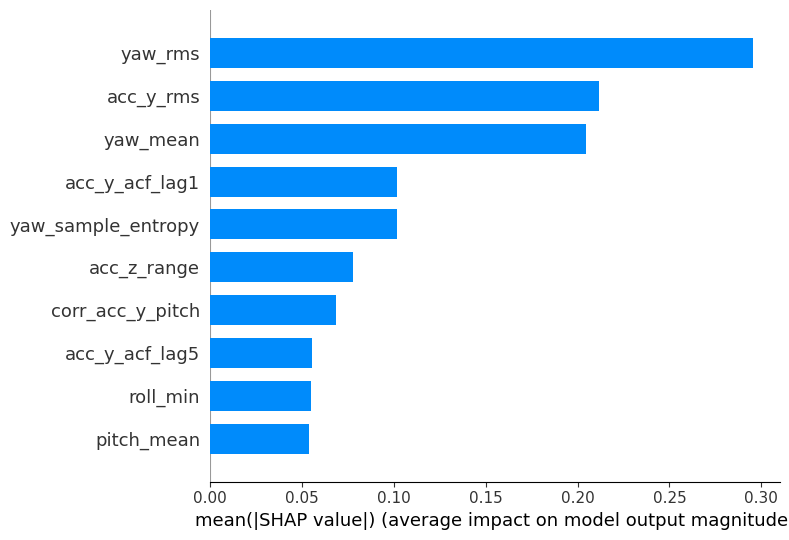

In [27]:
X_shap = StandardScaler().fit_transform(X_df.values)
xgb = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                    subsample=0.8, colsample_bytree=0.8,
                    eval_metric='mlogloss', random_state=373885, n_jobs=-1)
xgb.fit(X_shap, y)

explainer = shap.TreeExplainer(xgb)
sample_idx = np.random.default_rng(373885).choice(len(X_shap), size=min(2000, len(X_shap)), replace=False)
shap_values = explainer.shap_values(X_shap[sample_idx])
sv_normal = shap_values[:, :, 0] if shap_values.ndim == 3 else shap_values[0]

mean_abs_shap = pd.Series(np.abs(sv_normal).mean(axis=0), index=X_df.columns).sort_values(ascending=False)

print('Features by mean SHAP for P(Normal) (Top 10):')
top10_shap = mean_abs_shap.head(10).round(4).reset_index()
top10_shap.columns = ['Feature', 'Mean SHAP']
top10_shap.index = range(1, 11)
display(top10_shap)
mean_abs_shap.to_csv(TABLE_DIR / 'shap.csv')

shap.summary_plot(sv_normal, X_df.iloc[sample_idx], max_display=10, show=False, plot_type='bar')
plt.tight_layout()
out = FIG_DIR / 'shap_summary.png'
plt.savefig(out, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

### C6 — Convergent validity

Convergent validity requires an independent external criterion, which the UAH-DriveSet
does not provide. This is discussed in detail in the thesis.

---
## Output summary

In [28]:
print('Tables')
for f in sorted(TABLE_DIR.glob('*.csv')):
    print(f' {f.name:<48} {f.stat().st_size / 1024:>7.1f} KB')

print('\nFigures')
for f in sorted(FIG_DIR.glob('*.png')):
    print(f' {f.name:<48} {f.stat().st_size / 1024:>7.1f} KB')

Tables
 calibration_metrics.csv                              0.1 KB
 clustering_k3.csv                                    0.1 KB
 clustering_k6.csv                                    0.0 KB
 cont_tab_full_k3.csv                                 0.1 KB
 cont_tab_pca_k3.csv                                  0.1 KB
 discriminant_validity.csv                            0.4 KB
 durations.csv                                        0.3 KB
 feature_matrix.csv                               24102.0 KB
 feature_selection.csv                                6.1 KB
 feature_selection_report.csv                         6.1 KB
 metadata.csv                                         0.3 KB
 model_comparison.csv                                 0.4 KB
 pca_window_report.csv                                0.1 KB
 person_scores.csv                                    3.5 KB
 shap.csv                                             2.7 KB
 shap_importance.csv                                  2.7 KB
 split_half_relia